# 2. Inspect the Tanager methane scenes

Two neighbouring Tanager-1 strips were collected over the Santos Basin on 23 April 2025 in glint mode. They provide a compact test case before applying the method to the Southeast Asia use case.

This notebook checks the provider plume records, RGB images, methane quicklook, quality mask, and monthly background mosaic. It does not claim an independent retrieval yet. That test comes in Notebooks 5 and 6.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import geopandas as gpd
import pandas as pd

# Paths
from pathlib import Path
import sys

PACKAGE_ROOT = Path.cwd().resolve()
while not (PACKAGE_ROOT / "scripts").is_dir() and PACKAGE_ROOT.parent != PACKAGE_ROOT:
    PACKAGE_ROOT = PACKAGE_ROOT.parent
if not (PACKAGE_ROOT / "scripts").is_dir():
    raise FileNotFoundError("Run this notebook from the cloned submission folder or its notebooks folder.")

sys.path.insert(0, str(PACKAGE_ROOT / "scripts"))

FIG_DIR = PACKAGE_ROOT / 'figures'
ROOT = PACKAGE_ROOT
GHG_DIR = PACKAGE_ROOT / "data" / "ghg"

NORTH_ID = "20250423_134021_00_4001"   # northern strip - strip_C plume here
SOUTH_ID = "20250423_134026_31_4001"   # southern strip - strip_A + strip_B plumes

north = GHG_DIR / NORTH_ID
south = GHG_DIR / SOUTH_ID

print("Files in northern strip directory:")
for f in sorted(north.glob("*")):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

print()
print("Files in southern strip directory:")
for f in sorted(south.glob("*")):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")


Files in northern strip directory:
  ortho_beta_udm.tif  (0.1 MB)
  ortho_ql_ch4.tif  (0.0 MB)
  ortho_visual.tif  (2.2 MB)
  ql_ch4_json.geojson  (0.0 MB)
  thumbnail.png  (0.6 MB)

Files in southern strip directory:
  ortho_beta_udm.tif  (0.1 MB)
  ortho_ql_ch4.tif  (0.0 MB)
  ortho_visual.tif  (2.6 MB)
  ql_ch4_json.geojson  (0.0 MB)
  thumbnail.png  (0.7 MB)


## Provider plume records

The GeoJSON files contain the plume location, integrated mass enhancement, wind estimate, quality label, and provider emission rate. These values are the reference used later when checking the independent result.

In [2]:
# Load GeoJSON for both strips
def load_geojson(item_dir):
    p = item_dir / "ql_ch4_json.geojson"
    if not p.exists():
        print(f"  Not found: {p}")
        return None
    with open(p) as f:
        return json.load(f)

north_json = load_geojson(north)
south_json = load_geojson(south)

# Build a combined list used by all later cells
all_plume_features = []
if north_json:
    all_plume_features.extend(north_json["features"])
if south_json:
    all_plume_features.extend(south_json.get("features", []))

print("=== NORTHERN STRIP PLUMES ===")
if north_json:
    for i, feat in enumerate(north_json["features"]):
        p = feat["properties"]
        print(f"\nPlume {i+1}: {p['plume_id']}")
        print(f"  Emission:        {p['emission']:.1f} +/- {p['emission_uncertainty']:.1f} kg/hr")
        print(f"  IME:             {p['ime']:.2f} kg")
        print(f"  Fetch length:    {p['fetch']:.0f} m")
        print(f"  Wind:            {p['wind_speed_avg']:.2f} +/- {p['wind_speed_std']:.2f} m/s @ {p['wind_direction_avg']:.1f} deg")
        print(f"  Quality:         {p['plume_quality']}")
        print(f"  Algorithm:       {p['plume_provider']} v{p['plume_provider_version'].split(';')[0]}")

print("\n=== SOUTHERN STRIP PLUMES ===")
if south_json:
    for i, feat in enumerate(south_json.get("features", [])):
        p = feat["properties"]
        print(f"\nPlume {i+1}: {p['plume_id']}")
        print(f"  Emission:        {p['emission']:.1f} +/- {p['emission_uncertainty']:.1f} kg/hr")
        print(f"  IME:             {p['ime']:.2f} kg")
        print(f"  Fetch length:    {p['fetch']:.0f} m")
        print(f"  Wind:            {p['wind_speed_avg']:.2f} +/- {p['wind_speed_std']:.2f} m/s @ {p['wind_direction_avg']:.1f} deg")
        print(f"  Quality:         {p['plume_quality']}")
        print(f"  Algorithm:       {p['plume_provider']} v{p['plume_provider_version'].split(';')[0]}")

print("\n=== COMBINED TOTALS ===")
total_good = sum(f["properties"]["emission"] for f in all_plume_features
                 if f["properties"]["plume_quality"] == "good")
total_all  = sum(f["properties"]["emission"] for f in all_plume_features)
print(f"  Plumes detected:        {len(all_plume_features)} across both strips")
print(f"  Good-quality total:     {total_good:.1f} kg/hr  (~{total_good * 8760/1000:.0f} t/yr)")
print(f"  All detections total:   {total_all:.1f} kg/hr  (~{total_all * 8760/1000:.0f} t/yr)")
print()
print("Note: all plume IDs reference the northern strip - Carbon Mapper labels")
print("all detections from one overpass with the first strip's scene ID.")


=== NORTHERN STRIP PLUMES ===

Plume 1: 20250423_134021_00_4001_strip_C
  Emission:        795.7 +/- 232.3 kg/hr
  IME:             214.83 kg
  Fetch length:    990 m
  Wind:            1.02 +/- 0.22 m/s @ 101.7 deg
  Quality:         good
  Algorithm:       carbon_mapper vversion:v3

=== SOUTHERN STRIP PLUMES ===

Plume 1: 20250423_134021_00_4001_strip_A
  Emission:        309.5 +/- 147.3 kg/hr
  IME:             24.23 kg
  Fetch length:    420 m
  Wind:            1.49 +/- 0.45 m/s @ 298.5 deg
  Quality:         questionable
  Algorithm:       carbon_mapper vversion:v3

Plume 2: 20250423_134021_00_4001_strip_B
  Emission:        367.3 +/- 121.8 kg/hr
  IME:             291.10 kg
  Fetch length:    1770 m
  Wind:            0.62 +/- 0.18 m/s @ 100.2 deg
  Quality:         good
  Algorithm:       carbon_mapper vversion:v3

=== COMBINED TOTALS ===
  Plumes detected:        3 across both strips
  Good-quality total:     1163.0 kg/hr  (~10188 t/yr)
  All detections total:   1472.5 kg/hr  

## Quick scene preview

The thumbnails show the full acquisition strips and help confirm that the two files are in the expected location.

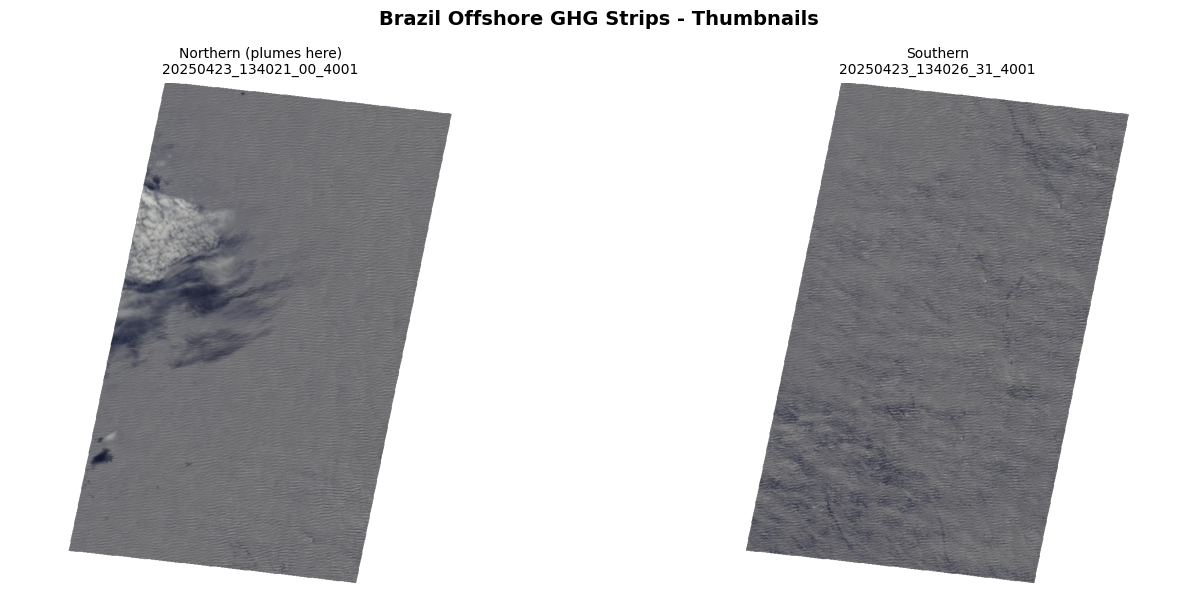

Saved to figures/02_scene_thumbnails.png


In [3]:
from PIL import Image   # part of Pillow, already installed

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Brazil Offshore GHG Strips - Thumbnails", fontsize=14, fontweight="bold")

for ax, (label, item_dir) in zip(axes, [("Northern (plumes here)", north), ("Southern", south)]):
    thumb_path = item_dir / "thumbnail.png"
    if thumb_path.exists():
        img = Image.open(thumb_path)
        ax.imshow(img)
        ax.set_title(f"{label}\n{item_dir.name}", fontsize=10)
    else:
        ax.text(0.5, 0.5, "Not downloaded yet", ha="center", va="center")
        ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_scene_thumbnails.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to figures/02_scene_thumbnails.png")


## RGB images and plume locations

The RGB products provide geographic context. Plume markers come from the provider GeoJSON, not from the RGB image.

Northern: 1340x1042 px  30 m res  EPSG:32723
Southern: 1336x1039 px  30 m res  EPSG:32723


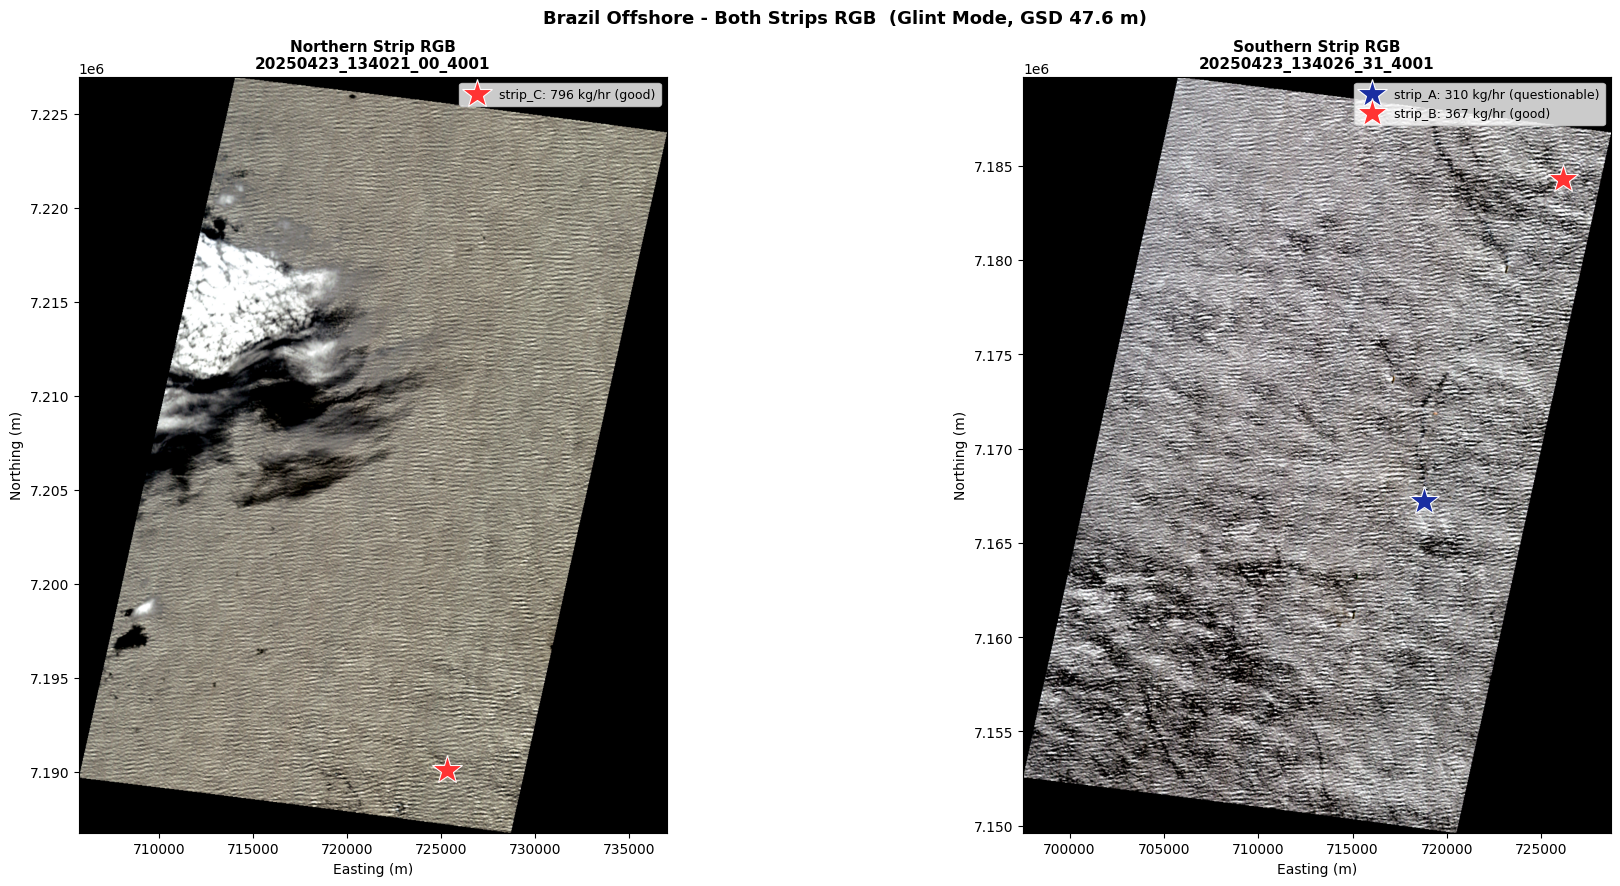

Saved: figures/02_rgb_and_plumes.png


In [4]:
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)


def stretch(band):
    """Percentile stretch to 0-1. Returns zeros if band has no positive values."""
    valid = band[band > 0]
    if len(valid) == 0:
        return np.zeros_like(band, dtype=float)
    p2, p98 = np.percentile(valid, [2, 98])
    return np.clip((band - p2) / (p98 - p2 + 1e-9), 0, 1)

GOOD_COLORS = ["#FF3333", "#FF8800"]   # red for first good plume, orange for second

def draw_plumes(ax, features, epsg):
    """
    Project `features` (list of GeoJSON features) to `epsg`, then draw each plume.
    Point geometry -> star marker. Polygon -> outline. Questionable -> grey dashed.
    """
    if not features:
        return
    gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326").to_crs(f"EPSG:{epsg}")
    good_idx = 0
    for _, row in gdf.iterrows():
        q = row["plume_quality"]
        strip = row["plume_id"].split("_strip_")[1]
        c  = GOOD_COLORS[good_idx % len(GOOD_COLORS)] if q == "good" else "#1A2EA1"
        ls = "-" if q == "good" else "--"
        if q == "good":
            good_idx += 1
        label = f"strip_{strip}: {row['emission']:.0f} kg/hr ({q})"
        geom  = row.geometry
        if geom.geom_type == "Point":
            ax.plot(geom.x, geom.y, marker="*", markersize=22, color=c,
                    markeredgecolor="white", markeredgewidth=0.8,
                    linestyle="none", label=label, zorder=5)
        else:
            xs, ys = geom.exterior.xy
            ax.plot(xs, ys, color=c, linewidth=2, linestyle=ls, label=label)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

strip_info = [
    ("Northern", north, NORTH_ID, north_json["features"] if north_json else []),
    ("Southern", south, SOUTH_ID, south_json.get("features", []) if south_json else []),
]

for ax, (label, item_dir, item_id, plume_feats) in zip(axes, strip_info):
    rgb_path_i = item_dir / "ortho_visual.tif"
    if not rgb_path_i.exists():
        ax.text(0.5, 0.5, f"{label}: ortho_visual.tif not found", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(f"{label} Strip", fontweight="bold")
        continue

    with rasterio.open(rgb_path_i) as src:
        rgb_i   = src.read([1, 2, 3])
        bounds_i = src.bounds
        epsg_i  = src.crs.to_epsg()
        print(f"{label}: {src.height}x{src.width} px  {src.res[0]:.0f} m res  EPSG:{epsg_i}")

    rgb_disp = np.stack([stretch(rgb_i[b]) for b in range(3)], axis=-1)

    extent_i = [bounds_i.left, bounds_i.right, bounds_i.bottom, bounds_i.top]
    ax.imshow(rgb_disp, extent=extent_i, origin="upper", aspect="equal")
    draw_plumes(ax, plume_feats, epsg_i)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_title(f"{label} Strip RGB\n{item_id}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.suptitle("Brazil Offshore - Both Strips RGB  (Glint Mode, GSD 47.6 m)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_rgb_and_plumes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/02_rgb_and_plumes.png")


## Provider methane quicklook

The methane GeoTIFF is Planet's processed quicklook. It is used as a visual reference, while the independent calculation in Notebook 6 starts from the basic radiance cube.

CH4 raster shape: 1339 x 1042
Data type:        uint8  (uint8 - Planet stores as integer 0-255)
Nodata value:     0.0  (0 = background/no-plume)
Value range (all): 0 – 135
Plume pixels (value > 0): 2469
Enhancement range (plume only): 1 – 135 ppm*m
Note: stored as uint8; values are ppm*m rounded to nearest integer.


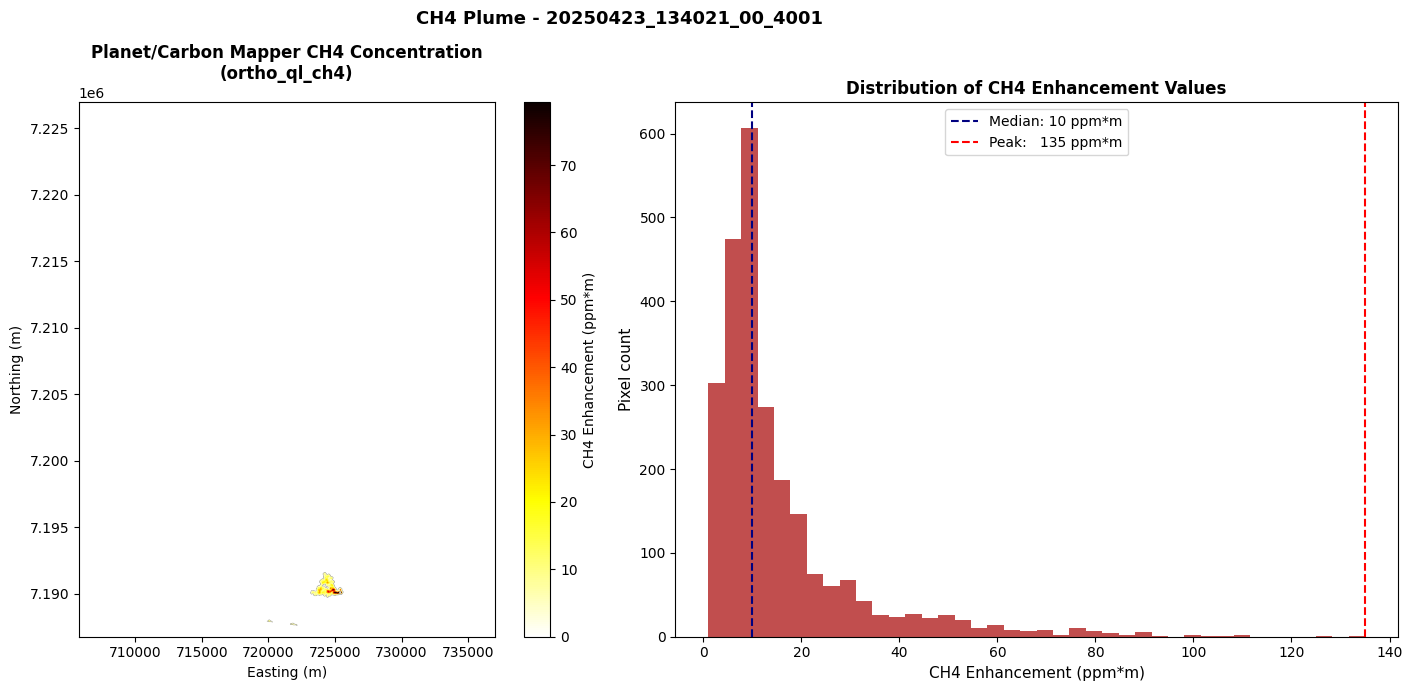

Saved: figures/02_provider_ch4_map.png


In [5]:
ch4_path = north / "ortho_ql_ch4.tif"

if not ch4_path.exists():
    print("ortho_ql_ch4.tif not downloaded yet.")
else:
    with rasterio.open(ch4_path) as src:
        ch4 = src.read(1).astype(float)
        nodata = src.nodata
        bounds_ch4 = src.bounds
        dtype = src.dtypes[0]
        print(f"CH4 raster shape: {src.height} x {src.width}")
        print(f"Data type:        {dtype}  (uint8 - Planet stores as integer 0-255)")
        print(f"Nodata value:     {nodata}  (0 = background/no-plume)")
        print(f"Value range (all): {ch4.min():.0f} – {ch4.max():.0f}")

    # Mask background (nodata=0 and any <=0)
    if nodata is not None:
        ch4[ch4 == nodata] = np.nan
    ch4[ch4 <= 0] = np.nan

    valid = ch4[~np.isnan(ch4)]
    print(f"Plume pixels (value > 0): {len(valid)}")
    if len(valid) > 0:
        print(f"Enhancement range (plume only): {valid.min():.0f} – {valid.max():.0f} ppm*m")
        print(f"Note: stored as uint8; values are ppm*m rounded to nearest integer.")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: CH4 concentration map
    ax = axes[0]
    extent = [bounds_ch4.left, bounds_ch4.right, bounds_ch4.bottom, bounds_ch4.top]
    vmax = np.nanpercentile(ch4, 99) if len(valid) > 0 else 1
    im = ax.imshow(ch4, extent=extent, origin="upper", cmap="hot_r",
                   vmin=0, vmax=vmax, aspect="equal")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("CH4 Enhancement (ppm*m)", fontsize=10)
    ax.set_title("Planet/Carbon Mapper CH4 Concentration\n(ortho_ql_ch4)", fontweight="bold")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

    # Right: histogram of enhancement values
    ax2 = axes[1]
    if len(valid) > 0:
        ax2.hist(valid.flatten(), bins=40, color="firebrick", edgecolor="none", alpha=0.8)
        ax2.axvline(np.nanmedian(ch4), color="navy", linestyle="--",
                    label=f"Median: {np.nanmedian(ch4):.0f} ppm*m")
        ax2.axvline(np.nanmax(ch4), color="red", linestyle="--",
                    label=f"Peak:   {np.nanmax(ch4):.0f} ppm*m")
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, "No plume pixels found", ha="center", va="center",
                 transform=ax2.transAxes)
    ax2.set_xlabel("CH4 Enhancement (ppm*m)", fontsize=11)
    ax2.set_ylabel("Pixel count", fontsize=11)
    ax2.set_title("Distribution of CH4 Enhancement Values", fontweight="bold")

    plt.suptitle(f"CH4 Plume - {NORTH_ID}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_provider_ch4_map.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: figures/02_provider_ch4_map.png")


## Pixel quality mask

The mask identifies cloud, cirrus, and missing pixels. These pixels are excluded from the spectral work.

Northern: clear=90.3%  unique UDM values=[0 1]
Southern: clear=93.7%  unique UDM values=[0 1]


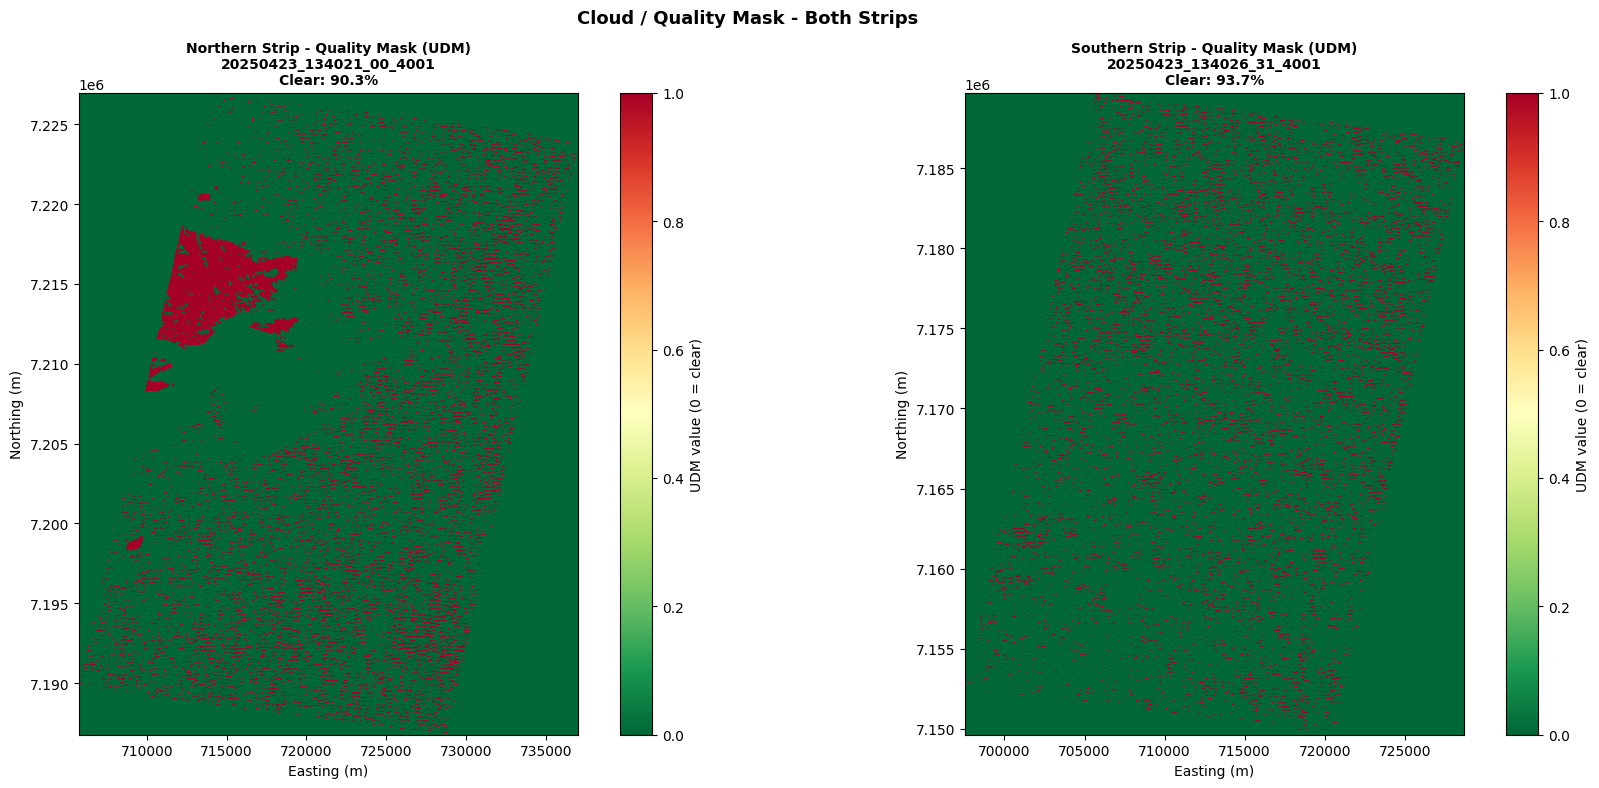

Saved: figures/02_quality_masks.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (label, item_dir, item_id) in zip(axes, [
        ("Northern", north, NORTH_ID),
        ("Southern", south, SOUTH_ID),
]):
    udm_path = item_dir / "ortho_beta_udm.tif"
    if not udm_path.exists():
        ax.text(0.5, 0.5, f"{label}: UDM not downloaded", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(f"{label} Strip - UDM", fontweight="bold")
        continue

    with rasterio.open(udm_path) as src:
        udm = src.read(1)
        bounds_udm = src.bounds

    clear_pct = 100 * np.mean(udm == 0)
    unique_vals = np.unique(udm)
    print(f"{label}: clear={clear_pct:.1f}%  unique UDM values={unique_vals}")

    extent = [bounds_udm.left, bounds_udm.right, bounds_udm.bottom, bounds_udm.top]
    im = ax.imshow(udm, extent=extent, origin="upper", cmap="RdYlGn_r",
                   interpolation="nearest", aspect="equal")
    plt.colorbar(im, ax=ax, label="UDM value (0 = clear)")
    ax.set_title(f"{label} Strip - Quality Mask (UDM)\n{item_id}\nClear: {clear_pct:.1f}%",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.suptitle("Cloud / Quality Mask - Both Strips", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_quality_masks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/02_quality_masks.png")


## Scene summary

The combined panel places the RGB image beside the provider methane quicklook for both strips. This is the visual reference for the spectral tests that follow.

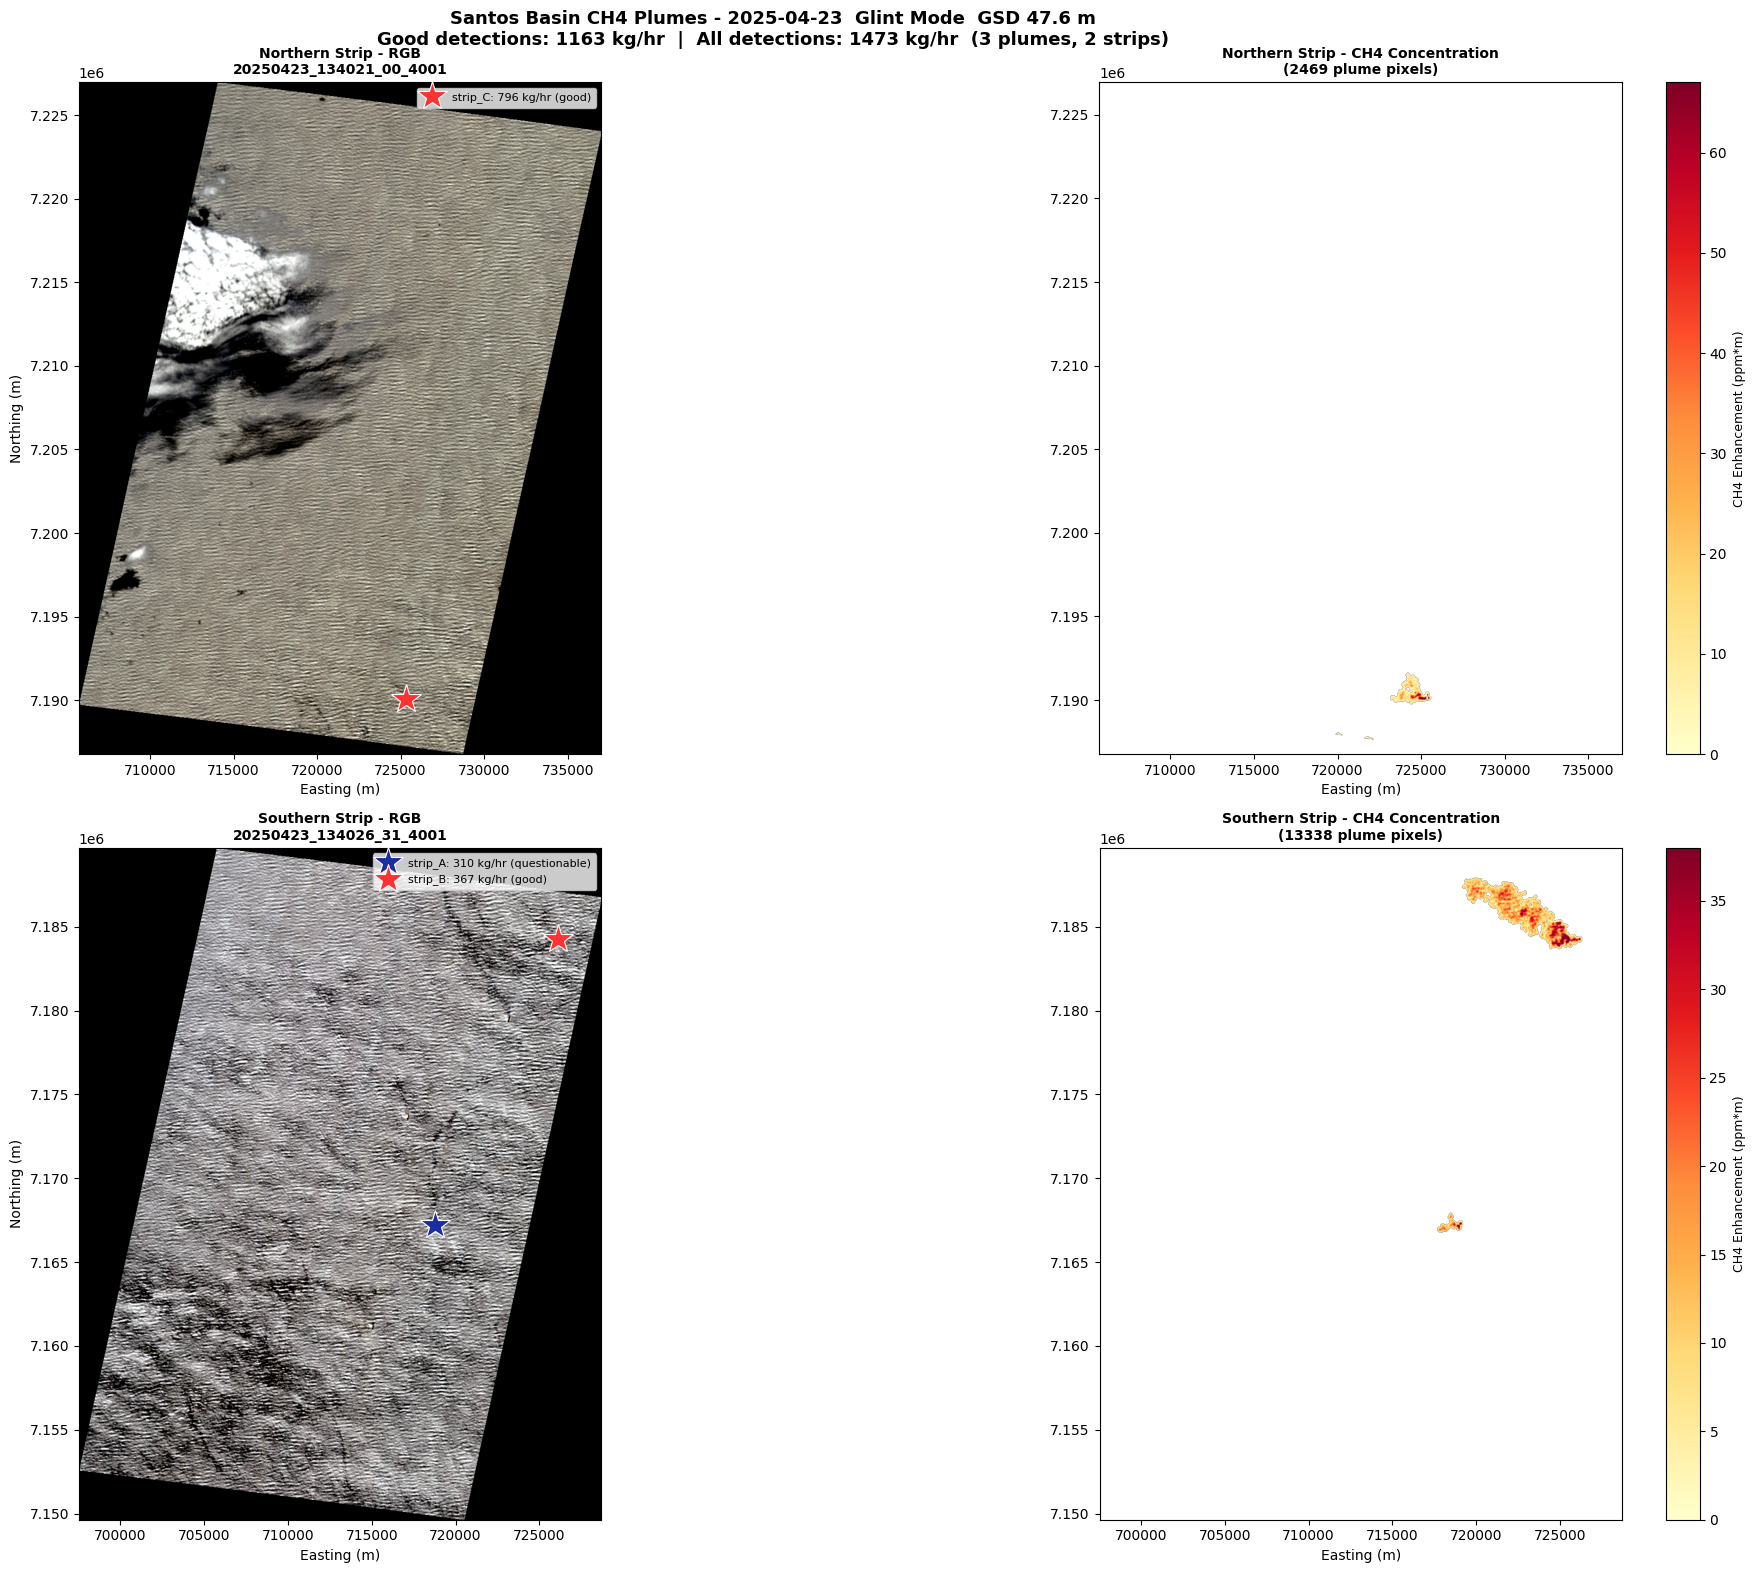

Saved: figures/02_scene_summary.png  <- main Phase 1 figure


In [7]:
strip_info = [
    ("Northern", north, NORTH_ID, north_json["features"] if north_json else []),
    ("Southern", south, SOUTH_ID, south_json.get("features", []) if south_json else []),
]

# Check all files exist before drawing
missing = [label for label, item_dir, _, _ in strip_info
           if not (item_dir / "ortho_visual.tif").exists()
           or not (item_dir / "ortho_ql_ch4.tif").exists()]
if missing:
    print(f"Missing files for: {missing}. Run: python scripts\\download_ghg.py")
else:
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    for row_idx, (label, item_dir, item_id, plume_feats) in enumerate(strip_info):

        # Load RGB (4-band; read only 1-3)
        with rasterio.open(item_dir / "ortho_visual.tif") as src:
            rgb_i    = src.read([1, 2, 3]).astype(float)
            bounds_r = src.bounds
            epsg_i   = src.crs.to_epsg()

        # Load CH4
        with rasterio.open(item_dir / "ortho_ql_ch4.tif") as src:
            ch4_i    = src.read(1).astype(float)
            nd_i     = src.nodata
            bounds_c = src.bounds
        if nd_i is not None:
            ch4_i[ch4_i == nd_i] = np.nan
        ch4_i[ch4_i <= 0] = np.nan

        rgb_disp = np.stack([stretch(rgb_i[b]) for b in range(3)], axis=-1)
        n_plume_px = int(np.sum(~np.isnan(ch4_i)))

        # Left: RGB
        ax_r = axes[row_idx, 0]
        ext_r = [bounds_r.left, bounds_r.right, bounds_r.bottom, bounds_r.top]
        ax_r.imshow(rgb_disp, extent=ext_r, origin="upper", aspect="equal")
        draw_plumes(ax_r, plume_feats, epsg_i)
        ax_r.legend(fontsize=8, loc="upper right")
        ax_r.set_title(f"{label} Strip - RGB\n{item_id}", fontsize=10, fontweight="bold")
        ax_r.set_xlabel("Easting (m)"); ax_r.set_ylabel("Northing (m)")

        # Right: CH4
        ax_c = axes[row_idx, 1]
        ext_c = [bounds_c.left, bounds_c.right, bounds_c.bottom, bounds_c.top]
        vmax_i = np.nanpercentile(ch4_i, 98) if n_plume_px > 0 else 1
        im_i = ax_c.imshow(ch4_i, extent=ext_c, origin="upper", cmap="YlOrRd",
                            vmin=0, vmax=vmax_i, aspect="equal")
        cbar_i = plt.colorbar(im_i, ax=ax_c, fraction=0.046, pad=0.04)
        cbar_i.set_label("CH4 Enhancement (ppm*m)", fontsize=9)
        # (plume markers removed from CH4 panel - show concentration only)
        ax_c.set_title(f"{label} Strip - CH4 Concentration\n({n_plume_px} plume pixels)",
                       fontsize=10, fontweight="bold")
        ax_c.set_xlabel("Easting (m)")

    total_good = sum(f["properties"]["emission"] for f in all_plume_features
                     if f["properties"]["plume_quality"] == "good")
    total_all_em = sum(f["properties"]["emission"] for f in all_plume_features)

    plt.suptitle(
        f"Santos Basin CH4 Plumes - 2025-04-23  Glint Mode  GSD 47.6 m\n"
        f"Good detections: {total_good:.0f} kg/hr  |  All detections: {total_all_em:.0f} kg/hr"
        f"  (3 plumes, 2 strips)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_scene_summary.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved: figures/02_scene_summary.png  <- main Phase 1 figure")


In [8]:
print("=" * 60)
print("SCENE SUMMARY - Santos Basin CH4 Plumes")
print("=" * 60)
print()
print("Scene metadata:")
print("  Date/time:       2025-04-23 13:40 UTC")
print("  Collection mode: Glint (ocean specular reflection for max SWIR SNR)")
print("  GSD:             47.6 m  (degraded from 32 m due to glint integration)")
print("  Cloud cover:     Northern 14%, Southern 9%")
print("  Sun elevation:   48.2 deg")
print("  Off-nadir:       26.3 deg")
print()

if all_plume_features:
    print(f"Planet/Carbon Mapper CH4 detections ({len(all_plume_features)} plumes, 2 strips):")
    total_em = 0
    total_good = 0
    for feat in all_plume_features:
        p = feat["properties"]
        strip = p["plume_id"].split("_strip_")[1]
        src_strip = "northern" if feat in (north_json or {}).get("features", []) else "southern"
        print(f"  strip_{strip} [{src_strip}]: "
              f"{p['emission']:.1f} +/- {p['emission_uncertainty']:.1f} kg/hr | "
              f"IME {p['ime']:.1f} kg | "
              f"fetch {p['fetch']:.0f} m | "
              f"{p['plume_quality']}")
        total_em += p["emission"]
        if p["plume_quality"] == "good":
            total_good += p["emission"]
    print()
    print(f"  Good-quality total:   {total_good:.1f} kg/hr  ~{total_good * 8760/1000:.0f} t/yr")
    print(f"  All detections total: {total_em:.1f} kg/hr  ~{total_em * 8760/1000:.0f} t/yr")
    print()
    print("Note: strip_A (questionable) should be treated with caution.")
    print("      strip_B and strip_C (both good) give a conservative baseline.")

print()
print("What we can say after Phase 1:")
print("  - 3 CH4 plume centroids detected across 2 adjacent strips in Santos Basin")
print("  - All named with northern strip scene ID (Carbon Mapper overpass convention)")
print("  - strip_C is in the northern strip footprint; strip_A and strip_B in southern")
print("  - Likely source: Santos Basin offshore oil/gas infrastructure (Tupi/Lula field)")
print("  - Glint mode essential - ocean gives bright, clean SWIR background")
print("  - ortho_ql_ch4 confirms pixel-level signal (uint8, 0-255, units ppm*m)")
print()
print("Next step: Phase 2 - download HDF5 spectral cube and examine raw spectra")
print("  python scripts\\download_ghg.py --hdf5")


SCENE SUMMARY - Santos Basin CH4 Plumes

Scene metadata:
  Date/time:       2025-04-23 13:40 UTC
  Collection mode: Glint (ocean specular reflection for max SWIR SNR)
  GSD:             47.6 m  (degraded from 32 m due to glint integration)
  Cloud cover:     Northern 14%, Southern 9%
  Sun elevation:   48.2 deg
  Off-nadir:       26.3 deg

Planet/Carbon Mapper CH4 detections (3 plumes, 2 strips):
  strip_C [northern]: 795.7 +/- 232.3 kg/hr | IME 214.8 kg | fetch 990 m | good
  strip_A [southern]: 309.5 +/- 147.3 kg/hr | IME 24.2 kg | fetch 420 m | questionable
  strip_B [southern]: 367.3 +/- 121.8 kg/hr | IME 291.1 kg | fetch 1770 m | good

  Good-quality total:   1163.0 kg/hr  ~10188 t/yr
  All detections total: 1472.5 kg/hr  ~12899 t/yr

Note: strip_A (questionable) should be treated with caution.
      strip_B and strip_C (both good) give a conservative baseline.

What we can say after Phase 1:
  - 3 CH4 plume centroids detected across 2 adjacent strips in Santos Basin
  - All named